# Cluster Analysis – Heart Failure Prediction Dataset
*PCA, UMAP, supervised UMAP, tree-based embeddings and baseline clustering on the original preprocessed feature space.*

This notebook evaluates how different dimensionality-reduction techniques influence clustering quality on the **Heart Failure Prediction Dataset**.

---
## Table of Contents
1. [Setup](#setup)  
    1.1 [Imports and Reproducibility](#imports-and-reproducibility)  
    1.2 [Data Loading and Feature Matrices](#data-loading)  
    1.3 [Feature Pruning](#feature-pruning)  

2. [Embedding Spaces](#embedding-spaces)  
    2.1 [Unsupervised Embeddings](#unsupervised-embeddings)  
    2.2 [Supervised Embeddings](#supervised-embeddings)  

3. [Cluster Analysis](#cluster-analysis)  
    3.1 [Clustering Algorithms](#clustering-algorithms)  
    3.2 [Baseline Clustering in Original Feature Space](#baseline-clustering-in-original-feature-space)  
    3.3 [Global Hyper-Parameter Search](#global-hyper-parameter-search)  
    3.4 [Detailed Evaluation of KMeans and Agglomerative](#detailed-evaluation-of-kmeans-and-agglomerative)  
    3.5 [Exploratory CLustering on Supervised Embeddings](#exploratory-clustering-on-supervised-embeddings)  
    3.6 [Leaderboards](#leaderboards)  

4. [Unsupervised Embedding Interpretation](#unsupervised-embedding-interpretation)  
    4.1 [Cluster Profiling (Unsupervised)](#cluster-profiling-unsupervised)  
    4.2 [Standardized Mean Differences (Unsupervised)](#smd-unsupervised)  
    4.3 [Target-Based Visualization (Unsupervised)](#target-visualization-unsupervised)

5. [Supervised Embedding Interpretation](#supervised-embedding-interpretation)  
    5.1 [Cluster Profiling (Supervised)](#cluster-profiling-supervised)  
    5.2 [Target-Driven Structure Analysis](#target-driven-structure-analysis)  

6. [Conclusions](#conclusions)  
    6.1 [Limitations](#limitations)  

<a id="setup"></a>
## Setup
---

<a id="imports-and-reproducibility"></a>
### Imports and Reproducibility

In [1]:
import os, sys, joblib, pandas as pd, numpy as np
sys.path.append(os.path.abspath(os.path.join('..')))

from sklearn.cluster import DBSCAN, KMeans, AgglomerativeClustering
from matplotlib import pyplot as plt
from sklearn.neighbors import NearestNeighbors
from scripts.dim_red.plots import plot_3d
from scripts.clustering import *
from copy import deepcopy
from scripts.eda.preprocessing.pipeline import build_preprocessing_pipeline

SEED = 42
TARGET_COL = "DEATH_EVENT"

<a id="data-loading"></a>
### Data Loading and Feature Matrices

In [2]:
X_cleaned = joblib.load('../outputs/eda/df_cleaned.pkl').iloc[:, :-1]
y = joblib.load('../outputs/eda/df_cleaned.pkl').iloc[:, -1]

X_pca = joblib.load('../outputs/dim_red/embeddings/X_pca.pkl')
X_umap_unsupervised = joblib.load('../outputs/dim_red/embeddings/X_umap_unsupervised.pkl')
X_mix = joblib.load('../outputs/dim_red/embeddings/X_mix.pkl')
X_umap_supervised = joblib.load('../outputs/dim_red/embeddings/X_umap_supervised.pkl')
X_umap_semisupervised = joblib.load('../outputs/dim_red/embeddings/X_umap_semisupervised.pkl')
X_umap_xgb = joblib.load('../outputs/dim_red/embeddings/X_umap_xgb.pkl')

<a id="feature-pruning"></a>
### Feature Pruning

In [3]:
_full_preproc = build_preprocessing_pipeline()
preproc_no_balance = deepcopy(_full_preproc)
preproc_no_balance.steps = preproc_no_balance.steps[:-1]   # no balancing for now

X_preprocessed = preproc_no_balance.fit_transform(X_cleaned, y)

In [4]:
cols_to_drop = ['high_blood_pressure', 'platelets', 'sex', 'creatinine_phosphokinase', 'anaemia', 'smoking', 'diabetes']
X_preprocessed = X_preprocessed.drop(columns=cols_to_drop)

X_preprocessed.shape

(299, 5)

- Final preprocessed matrix: **299 patients × 5 features**.  
- Dropped 7 weaker and not important to keep the clustering space compact and less noisy (based on mutual information score plot from EDA).

<a id="embedding-spaces"></a>
## Embedding Spaces
---

<a id="unsupervised-embeddings"></a>
### Unsupervised Embeddings

`PCA`, `UMAP` and the mixed embedding (`mix`) are treated as **unsupervised** representations that do not use label information.

In [5]:
embeddings_unsupervised = {
    "pca":  X_pca,
    "umap": X_umap_unsupervised,
    "mix":  X_mix,
}

<a id="supervised-embeddings"></a>
### Supervised Embeddings

`Supervised UMAP`, `semi-supervised UMAP` and `XGBoost leaf embeddings` are **label-informed** and encode information about `DEATH_EVENT`.

In [6]:
embeddings_supervised = {
    "umap_supervised":     X_umap_supervised,
    "umap_semisupervised": X_umap_semisupervised,
    "umap_xgb":            X_umap_xgb,
}

In [7]:
embeddings_all = {
    **embeddings_unsupervised,
    **embeddings_supervised,
}

<a id="cluster-analysis"></a>
## Cluster Analysis
---

Several precomputed embedding spaces are used:

- **Baseline**: original preprocessed feature space (`X_p`)
- **Unsupervised embeddings**: `PCA`, `UMAP`, and a mixed embedding (`mix`)
- **Supervised embeddings**: `supervised UMAP`, `semi-supervised UMAP`, and `XGBoost leaf-based embeddings`

These representations are used as inputs to clustering algorithms to study how well different spaces reveal hidden patient structure.

<a id="clustering-algorithms"></a>
### Clustering Algorithms

To evaluate how different embedding spaces support unsupervised structure, three complementary clustering algorithms are applied. These methods represent distinct theoretical paradigms and allow to compare density-based, centroid-based, and hierarchical approaches. These three algorithms complement each other and help assess how well each embedding reveals latent structure.

**DBSCAN**  
- Density-based clustering method  
- Automatically identifies noise and outliers  
- Excels when clusters have irregular or non-spherical shapes  
- Requires tuning of `eps` and `min_samples`

**KMeans**  
- Centroid-based algorithm minimizing within-cluster variance  
- Produces compact, spherical clusters  
- Requires specifying the number of clusters `k`  
- Sensitive to initialization (multiple `n_init` used for stability)

**Agglomerative Clustering**  
- Hierarchical clustering that builds clusters through iterative merging  
- Supports various linkage criteria (Ward, Complete, Average)  
- Flexible in capturing different cluster geometries  
- Does not automatically detect the number of clusters

<a id="baseline-clustering-in-original-feature-space"></a>
### Baseline Clustering in Original Feature Space

#### Hyper-Parameter Search

In [8]:
db_best_pre = gridsearch_dbscan(X=X_preprocessed)
km_best_pre = gridsearch_kmeans_params(X=X_preprocessed, ks=range(2, 8), n_inits=(25, 50))
ag_best_pre = gridsearch_agglomerative_params(X=X_preprocessed, ks=range(2, 8), linkages=("ward", "complete", "average"), metrics=("euclidean", "manhattan", "cosine"))

params_db_pre = db_best_pre["params"]
params_km_pre = km_best_pre["params"]
params_ag_pre = ag_best_pre["params"]

print("DBSCAN(best on PRE):", params_db_pre)
print("KMeans(best on PRE):", params_km_pre)
print("Agglomerative(best on PRE):", params_ag_pre)

DBSCAN(best on PRE): {'eps': 0.3, 'min_samples': 3}
KMeans(best on PRE): {'n_clusters': 4, 'n_init': 25}
Agglomerative(best on PRE): {'n_clusters': 4, 'linkage': 'ward', 'metric': 'euclidean'}


- **KMeans** and **Agglomerative** both favour **4 clusters** in the original preprocessed feature space.  
- **DBSCAN** finds a reasonable density structure with `eps≈0.3`, but still needs evaluation via clustering metrics.

#### Refitting with the Best Parameters

In [9]:
db_pre = DBSCAN(**params_db_pre)
km_pre = KMeans(**params_km_pre)
ag_pre = AgglomerativeClustering(**params_ag_pre)

labels_db_pre = db_pre.fit_predict(X_preprocessed)
labels_km_pre = km_pre.fit_predict(X_preprocessed)
labels_ag_pre = ag_pre.fit_predict(X_preprocessed)

scores_db_pre = show_scores("DBSCAN on PRE", X_preprocessed, labels_db_pre, y)
scores_km_pre = show_scores("KMeans on PRE",  X_preprocessed, labels_km_pre, y)
scores_ag_pre = show_scores("Agglomerative on PRE", X_preprocessed, labels_ag_pre, y)

[DBSCAN on PRE] -> clusters=2, noise=6.0%, sil=0.1929350288785158, CH=7.179963263467892, DB=3.3126208537485726, ARI=0.05352359780522231, NMI=0.026625328083115494, V=0.026625328083115494
[KMeans on PRE] -> clusters=4, noise=0.0%, sil=0.23024879333638712, CH=85.62228648847233, DB=1.3760149739147922, ARI=0.12513309623610763, NMI=0.11820123417567888, V=0.11820123417567888
[Agglomerative on PRE] -> clusters=4, noise=0.0%, sil=0.2158220591396888, CH=77.07144733866994, DB=1.3837207069314446, ARI=0.15560541925945753, NMI=0.13509076156687183, V=0.1350907615668718


- **KMeans (4 clusters)** gives the **best overall scores** (highest silhouette / NMI) in the original feature space.  
- **Agglomerative (4 clusters)** is slightly worse but comparable.  
- **DBSCAN (2 clusters)** shows **lower silhouette and low NMI** with some noise points → less suitable as a baseline.

#### Visualisation of Baseline Clusters in 3D Embeddings

In [10]:
for name, X_emb in embeddings_unsupervised.items():
    print(f"\n=== Baseline clusters visualised in {name} ===")
    plot_3d(X3d=X_emb, y=labels_db_pre, algorithm=f"DBSCAN (PRE, {name})", target_name="cluster", data_name=name, show=True)
    plot_3d(X3d=X_emb, y=labels_km_pre, algorithm=f"KMeans (PRE, {name})", target_name="cluster", data_name=name, show=True)
    plot_3d(X3d=X_emb, y=labels_ag_pre, algorithm=f"Agglomerative (PRE, {name})", target_name="cluster", data_name=name, show=True)


=== Baseline clusters visualised in pca ===



=== Baseline clusters visualised in umap ===



=== Baseline clusters visualised in mix ===


- **DBSCAN** consistently fails to discover meaningful structure. Zlmost all samples fall into one large cluster, with only a few noise points across PCA, UMAP, and MIX. This indicates the absence of density-separated groups in the original features.

- **KMeans** and **Agglomerative** (4 clusters) provide the most stable and interpretable solutions.
  - `PCA`: clusters are present but overlapping and weakly defined.
  - `UMAP`: produces distinct, more separated regions, revealing stronger latent structure.
  - `MIX`: the cleanest and most linear cluster separation; suggests an underlying gradient-like progression in patient characteristics.

- Across embeddings, KMeans and Agglomerative consistently find 4 moderately separable clusters, though the strength and geometry differ by embedding.

- Overall, the original feature space shows weak intrinsic cluster structure, but non-linear embeddings-especially UMAP and MIX—reveal more pronounced groupings.

<a id="global-hyper-parameter-search"></a>
### Global Hyper-Parameter Search

For each embedding space (PCA, UMAP, MIX, supervised UMAP variants), a full hyper-parameter search using three clustering algorithms is performed:

1. **DBSCAN**  
   - estimates density structure using a k-distance plot  
   - parameters tuned automatically via `gridsearch_dbscan`

2. **KMeans**  
   - evaluated across a range of cluster counts `k=2..8`  
   - multiple initializations (`n_inits`) used for robustness

3. **Agglomerative Clustering**  
   - searched over several linkage strategies (Ward, Complete, Average)  
   - and multiple distance metrics (Euclidean, Manhattan, Cosine)

This loop produces the best parameters and performance metrics for each (embedding × algorithm) combination, which are later used in the leaderboards.


=== Embedding: PCA ===


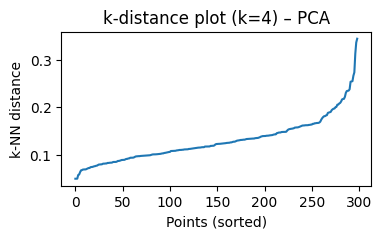

[DBSCAN] best params: {'eps': 0.2, 'min_samples': 3}
[KMeans] best params: {'n_clusters': 5, 'n_init': 10}
[Agglomerative] best params: {'n_clusters': 5, 'linkage': 'average', 'metric': 'euclidean'}

=== Embedding: UMAP ===


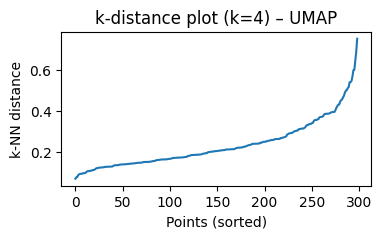

[DBSCAN] best params: {'eps': 0.8, 'min_samples': 3}
[KMeans] best params: {'n_clusters': 4, 'n_init': 20}
[Agglomerative] best params: {'n_clusters': 4, 'linkage': 'complete', 'metric': 'manhattan'}

=== Embedding: MIX ===


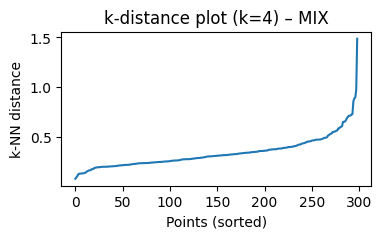

[DBSCAN] best params: {'eps': 0.5, 'min_samples': 5}
[KMeans] best params: {'n_clusters': 4, 'n_init': 20}
[Agglomerative] best params: {'n_clusters': 5, 'linkage': 'average', 'metric': 'manhattan'}

=== Embedding: UMAP_SUPERVISED ===


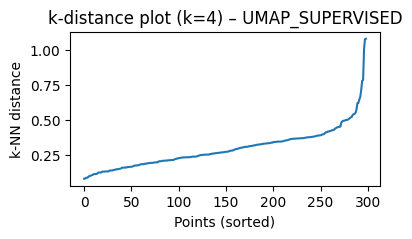

[DBSCAN] best params: {'eps': 1.2, 'min_samples': 3}
[KMeans] best params: {'n_clusters': 2, 'n_init': 10}
[Agglomerative] best params: {'n_clusters': 2, 'linkage': 'ward', 'metric': 'euclidean'}

=== Embedding: UMAP_SEMISUPERVISED ===


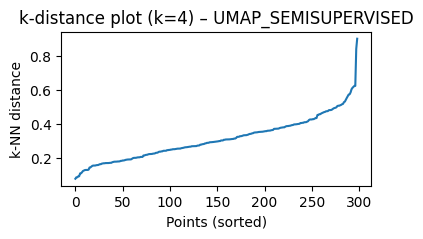

[DBSCAN] best params: {'eps': 1.2, 'min_samples': 3}
[KMeans] best params: {'n_clusters': 2, 'n_init': 10}
[Agglomerative] best params: {'n_clusters': 2, 'linkage': 'ward', 'metric': 'euclidean'}

=== Embedding: UMAP_XGB ===


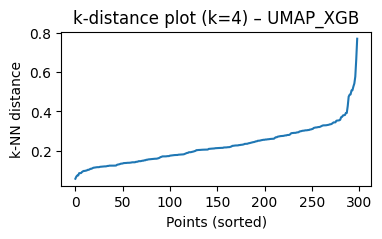

[DBSCAN] best params: {'eps': 0.8, 'min_samples': 10}
[KMeans] best params: {'n_clusters': 3, 'n_init': 20}
[Agglomerative] best params: {'n_clusters': 3, 'linkage': 'ward', 'metric': 'euclidean'}


In [11]:
dbscan_best = {}
kmeans_best = {}
agglom_best = {}
X_orig = X_preprocessed.copy()

for name, X_orig in embeddings_all.items():
    print(f"\n=== Embedding: {name.upper()} ===")
    
    # --- 1) DBSCAN ---
    k = 4
    nbrs = NearestNeighbors(n_neighbors=k).fit(X_orig)
    distances, _ = nbrs.kneighbors(X_orig)
    kd = np.sort(distances[:, k - 1])
    
    plt.figure(figsize=(4, 2))
    plt.plot(kd)
    plt.title(f"k-distance plot (k=4) – {name.upper()}")
    plt.xlabel("Points (sorted)")
    plt.ylabel("k-NN distance")
    plt.show()
    
    db_best = gridsearch_dbscan(X=X_orig)
    dbscan_best[name] = db_best
    print("[DBSCAN] best params:", db_best["params"])
    
    # --- 2) KMeans ---
    km_best = gridsearch_kmeans_params(X_orig, ks=range(2, 8), n_inits=(10, 20),)
    kmeans_best[name] = km_best
    km_params  = km_best.get("params", km_best)
    print("[KMeans] best params:", km_params)
    
    # --- 3) Agglomerative ---
    ag_best = gridsearch_agglomerative_params(X_orig, ks=range(2, 8), linkages=("ward", "complete", "average"), metrics=("euclidean", "manhattan", "cosine"))
    agglom_best[name] = ag_best
    ag_params  = ag_best.get("params", ag_best)
    print("[Agglomerative] best params:", ag_params)


- For **unsupervised embeddings (PCA, UMAP, MIX)**:
  - Best **KMeans / Agglomerative** solutions use between **4 and 5 clusters**  
    - **PCA**: prefers **5 clusters**
    - **UMAP** and **MIX**: prefer **4 clusters**  
  - **DBSCAN** needs **moderate `eps` (0.2–0.8)** and **low `min_samples` (3–5)** to form non-trivial clusters.
- For **supervised embeddings (UMAP_SUPERVISED / UMAP_SEMISUPERVISED / UMAP_XGB)**:
  - Best **KMeans / Agglomerative** pick **2-3 clusters**.
  - **DBSCAN** works with `eps = 0.8` and `1.2` with `min_samples = 3` or `10`, reinforcing a **very compact 2-cluster structure**.

<a id="detailed-evaluation-of-kmeans-and-agglomerative"></a>
### Detailed Evaluation of KMeans and Agglomerative

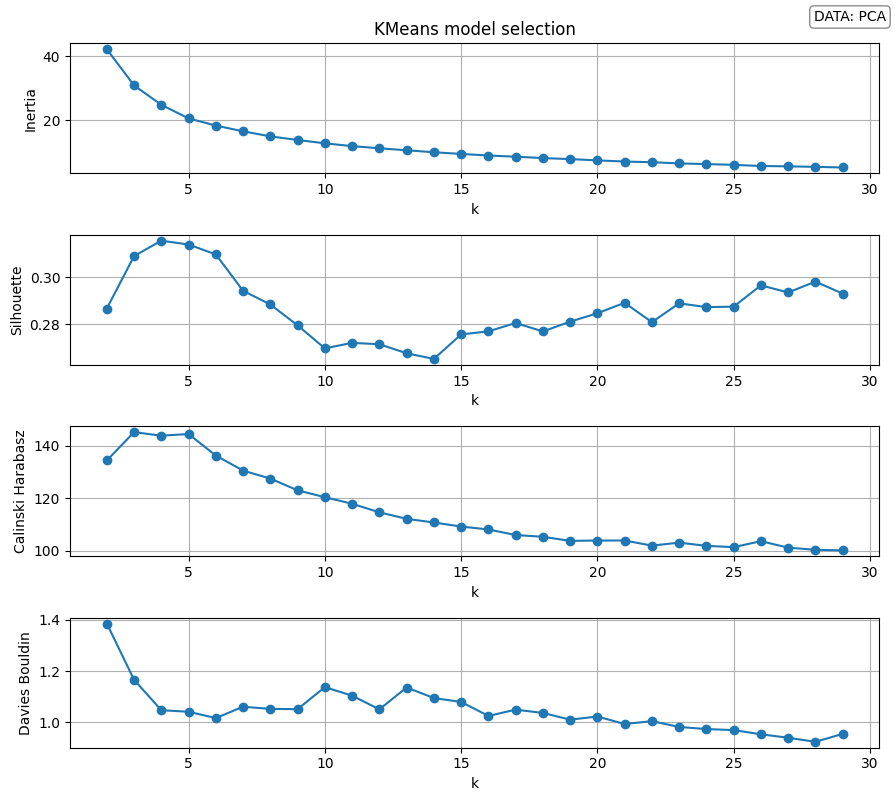

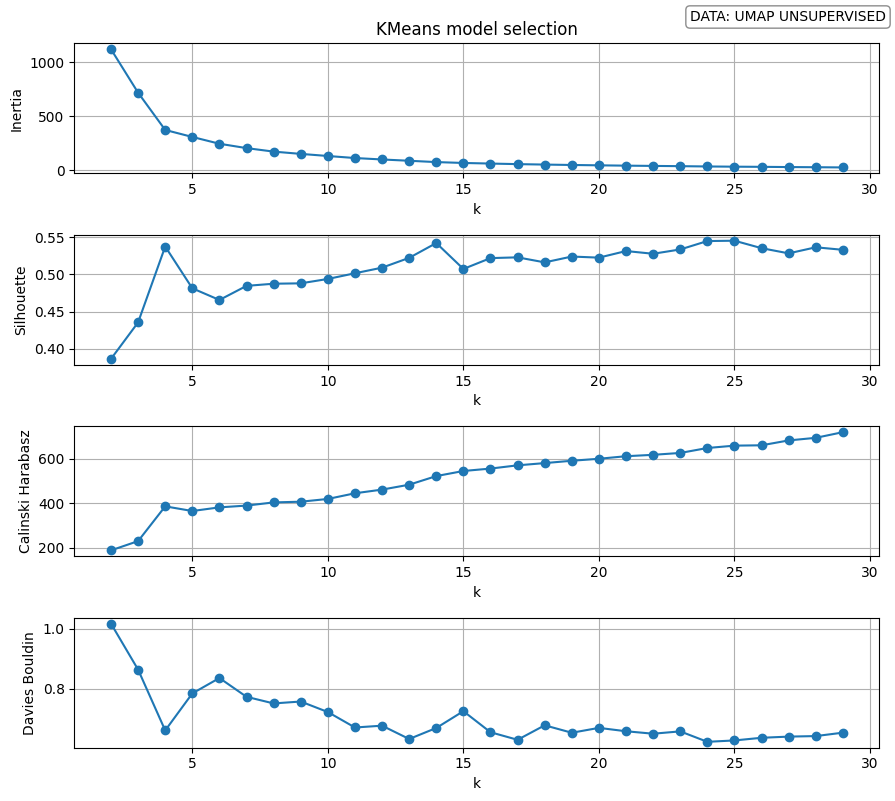

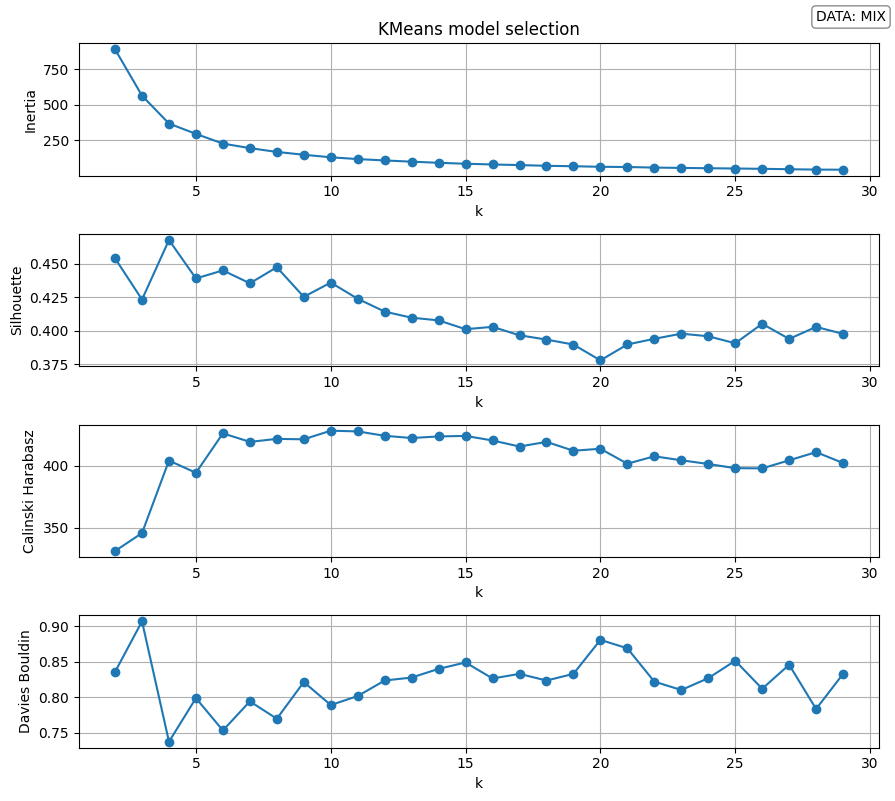


KMeans on PCA
{'inertia': 29, 'silhouette': 4, 'calinski_harabasz': 3, 'davies_bouldin': 28}

KMeans on UMAP_UNSUPERVISED
{'inertia': 29, 'silhouette': 25, 'calinski_harabasz': 29, 'davies_bouldin': 24}

KMeans on MIX
{'inertia': 29, 'silhouette': 4, 'calinski_harabasz': 10, 'davies_bouldin': 4}


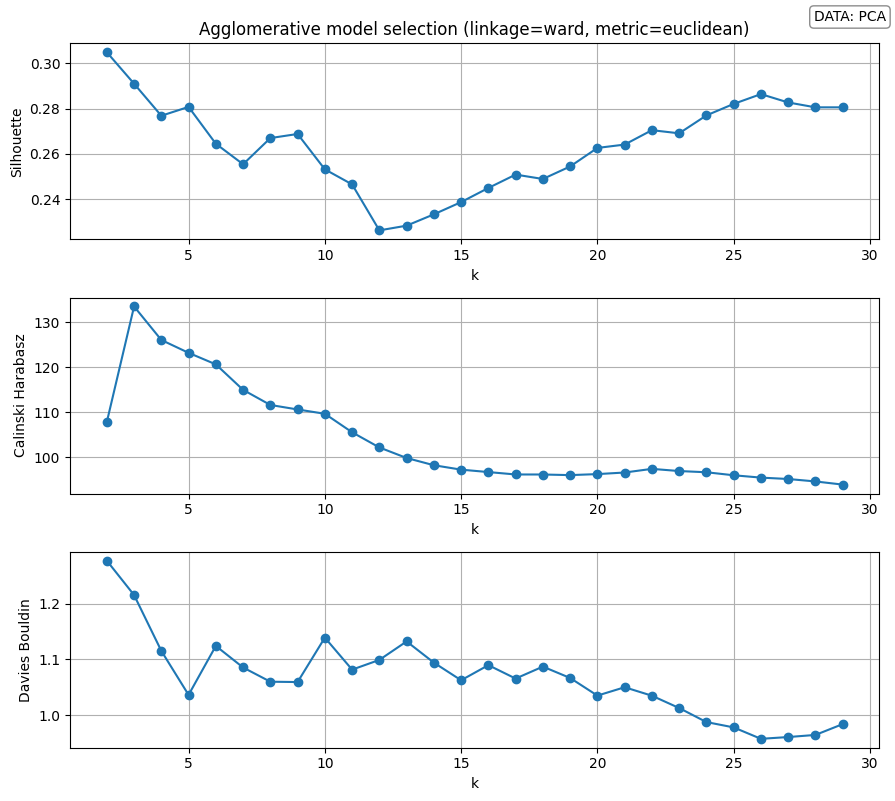

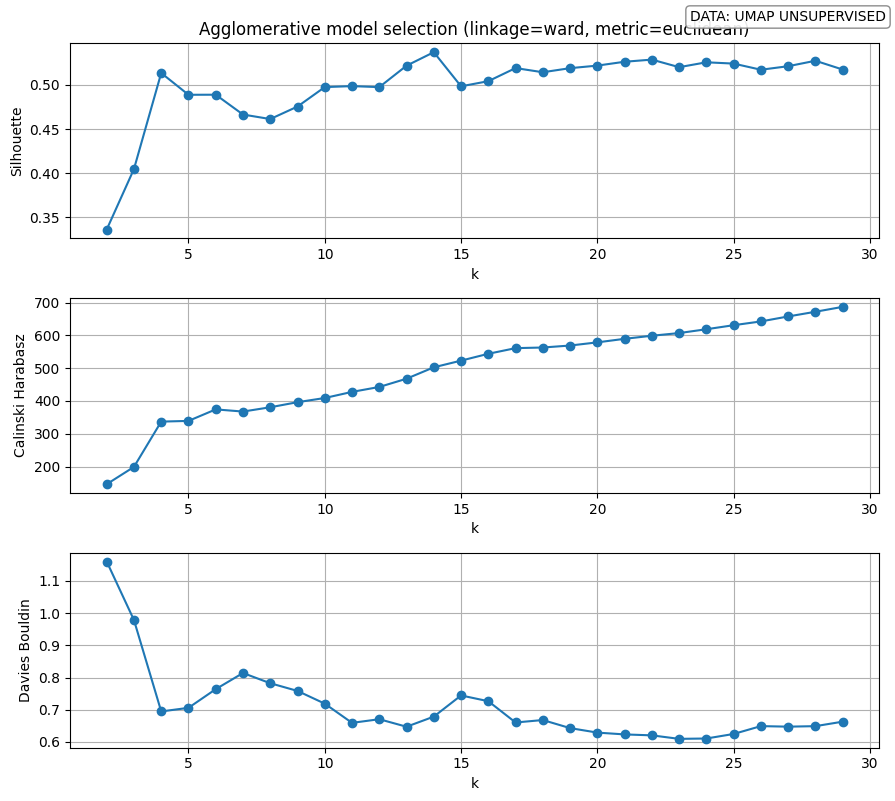

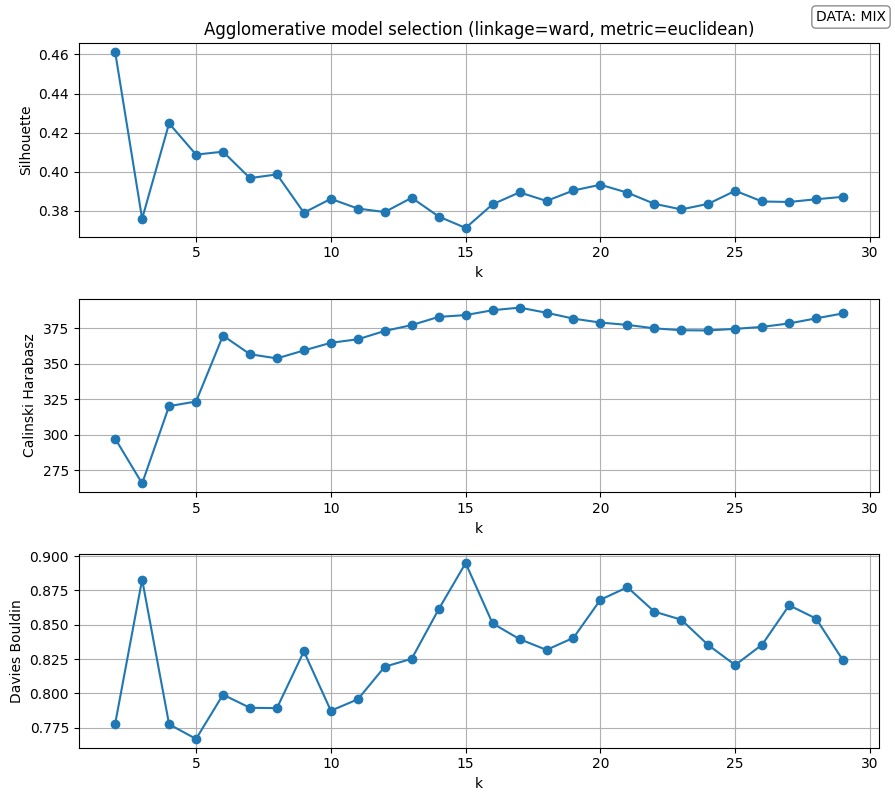


Agglomerative on PCA
{'silhouette': 2, 'calinski_harabasz': 3, 'davies_bouldin': 26}

Agglomerative on UMAP_UNSUPERVISED
{'silhouette': 14, 'calinski_harabasz': 29, 'davies_bouldin': 23}

Agglomerative on MIX
{'silhouette': 2, 'calinski_harabasz': 17, 'davies_bouldin': 5}


In [12]:
# KMEANS
kmeans_results = {
    'pca': select_k_kmeans (X_pca,  k_range=range(2, 30), n_init=50, data_name="PCA"),
    'umap_unsupervised': select_k_kmeans(X_umap_unsupervised, k_range=range(2, 30), n_init=50, data_name="UMAP UNSUPERVISED"),
    'MIX': select_k_kmeans(X_mix,  k_range=range(2, 30), n_init=50, data_name="MIX"),
}

for name, res in kmeans_results.items():
    print(f"\nKMeans on {name.upper()}")
    print(res.best_by_metric)
    
# AGGLOMERATIVE
agg_results = {
    'pca': select_k_agglomerative(X_pca,  k_range=range(2, 30), data_name="PCA"),
    'umap_unsupervised': select_k_agglomerative(X_umap_unsupervised, k_range=range(2, 30), data_name="UMAP UNSUPERVISED"),
    'MIX': select_k_agglomerative(X_mix,  k_range=range(2, 30), data_name="MIX"),
}

for name, res in agg_results.items():
    print(f"\nAgglomerative on {name.upper()}")
    print(res.best_by_metric)

- Internal validation often **pushes for high k (e.g. k≈20–30)**, especially for inertia / Calinski-Harabasz.  
- To keep clusters **interpretable**, we treat these metrics as **guidance only** and later focus on **small k (≈2–7)** chosen via the global search + visual inspection.

<a id="exploratory-clustering-on-supervised-embeddings"></a>
### Exploratory Clustering on Supervised Embeddings

The following section applies clustering to:

- **Supervised UMAP**, **semi-supervised UMAP**, and **XGBoost leaf + UMAP**,  
  which are **label-informed** embeddings (they explicitly encode information about `DEATH_EVENT`).


Because supervised embeddings incorporate outcome information, clusters formed in these spaces **cannot be interpreted** as purely data-driven clinical subgroups. Instead, they reflect how a model organizes patients when the target label is available.

**Methodological distinction:**
- Unsupervised clusters → natural patient subgroups (data-driven)
- Supervised clusters → outcome-informed risk strata (model-driven)

Therefore, the results in this section are used primarily for **visualization, exploratory inspection, and understanding model behavior**, not for deriving final clinical conclusions.

In [13]:
rows_ex = []

exploratory_params_km = {
    "umap_supervised":     {"k": 2, "n_init": 10},
    "umap_semisupervised": {"k": 2, "n_init": 10},
    "umap_xgb":            {"k": 3, "n_init": 20},
}

for name, X_emb in embeddings_supervised.items():
    p = exploratory_params_km[name]
    km = KMeans(n_clusters=p["k"], n_init=p["n_init"])
    labels = km.fit_predict(X_emb)

    fig = plot_3d(X3d=X_emb, y=labels, algorithm=f"[EXPLORATORY] KMeans on {name}", target_name="cluster", data_name=name.upper())
    display(fig)

Supervised embeddings reveal much stronger and clinically meaningful structure than unsupervised ones. They consistently produce 2–3 fully separated and interpretable clusters.

<a id="leaderboards"></a>
### Leaderboards

#### Unsupervised Embeddings

In [14]:
board_unsupervised = build_global_leaderboard(embeddings_unsupervised)
ordered_unsupervised = rank_leaderboard(board_unsupervised)

rows_unsup = []
for i, r in enumerate(ordered_unsupervised, 1):
    m = r["metrics"]
    rows_unsup.append({
        "Embedding": r["emb"].upper(),
        "Algorithm": r["algo"].upper(),
        "Params": str(r["params"]),
        "Clusters": m.get("n_clusters"),
        "Silhouette": round(m.get("silhouette"), 4),
        "Calinski-Harabasz": round(m.get("calinski_harabasz"), 2),
        "Davies-Bouldin": round(m.get("davies_bouldin"), 4),
    })

df_leader_unsup = pd.DataFrame(rows_unsup)
df_leader_unsup.style    .background_gradient(subset=["Silhouette"], cmap="Greens")    .background_gradient(subset=["Calinski-Harabasz"], cmap="Blues")    .background_gradient(subset=["Davies-Bouldin"], cmap="Reds_r")    .format({"Silhouette": "{:.4f}", "Calinski-Harabasz": "{:.2f}", "Davies-Bouldin": "{:.4f}"})


,Embedding,Algorithm,Params,Clusters,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,UMAP,KMEANS,"{'n_clusters': 4, 'n_init': 25}",4,0.5373,385.53,0.6601
1,UMAP,AGGLOMERATIVE,"{'n_clusters': 4, 'linkage': 'complete', 'metric': 'manhattan'}",4,0.5218,354.01,0.6842
2,MIX,KMEANS,"{'n_clusters': 4, 'n_init': 25}",4,0.4678,404.05,0.7384
3,MIX,AGGLOMERATIVE,"{'n_clusters': 5, 'linkage': 'average', 'metric': 'manhattan'}",5,0.4537,383.32,0.7430
4,UMAP,DBSCAN,"{'eps': 0.8, 'min_samples': 3}",3,0.4442,211.95,0.9072
5,MIX,DBSCAN,"{'eps': 0.5, 'min_samples': 5}",8,0.3493,160.96,1.8452
6,PCA,KMEANS,"{'n_clusters': 5, 'n_init': 10}",5,0.3137,144.50,1.0407
7,PCA,DBSCAN,"{'eps': 0.2, 'min_samples': 3}",2,0.2848,2.59,2.8923
8,PCA,AGGLOMERATIVE,"{'n_clusters': 5, 'linkage': 'average', 'metric': 'euclidean'}",5,0.2787,120.70,0.9766


- **UMAP + KMeans (4 clusters)** achieved the **best overall performance**, with the highest Silhouette score and strong Calinski–Harabasz value - well-separated and compact clusters.
- **UMAP-based embeddings** consistently outperform PCA and MIX across all clustering algorithms - UMAP captures the data structure more effectively.
- **Agglomerative clustering on UMAP** also performs well, but slightly worse than KMeans.
- **DBSCAN** works reasonably on UMAP but is **clearly less stable**, showing lower cluster quality and sensitivity to parameters.
- **PCA-based embeddings** give the weakest results overall, regardless of the clustering method.

UMAP embeddings combined with **KMeans (k=4)** are the most reliable choice for.

#### Supervised Embedings

In [15]:
board_supervised = build_global_leaderboard(embeddings_supervised)
ordered_supervised = rank_leaderboard(board_supervised)

rows_sup = []
for i, r in enumerate(ordered_supervised, 1):
    m = r["metrics"]
    rows_sup.append({
        "Embedding": r["emb"].upper(),
        "Algorithm": r["algo"].upper(),
        "Params": str(r["params"]),
        "Clusters": m.get("n_clusters"),
        "Silhouette": round(m.get("silhouette"), 4),
        "Calinski-Harabasz": round(m.get("calinski_harabasz"), 2),
        "Davies-Bouldin": round(m.get("davies_bouldin"), 4),
    })

df_leader_sup = pd.DataFrame(rows_sup)
df_leader_sup.style    .background_gradient(subset=["Silhouette"], cmap="Greens")    .background_gradient(subset=["Calinski-Harabasz"], cmap="Blues")    .background_gradient(subset=["Davies-Bouldin"], cmap="Reds_r")    .format({"Silhouette": "{:.4f}", "Calinski-Harabasz": "{:.2f}", "Davies-Bouldin": "{:.4f}"})


,Embedding,Algorithm,Params,Clusters,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,UMAP_SUPERVISED,KMEANS,"{'n_clusters': 2, 'n_init': 10}",2,0.9066,12302.72,0.1397
1,UMAP_SUPERVISED,AGGLOMERATIVE,"{'n_clusters': 2, 'linkage': 'ward', 'metric': 'euclidean'}",2,0.9066,12302.72,0.1397
2,UMAP_SEMISUPERVISED,KMEANS,"{'n_clusters': 2, 'n_init': 10}",2,0.8246,3523.09,0.2429
3,UMAP_SEMISUPERVISED,AGGLOMERATIVE,"{'n_clusters': 2, 'linkage': 'ward', 'metric': 'euclidean'}",2,0.8246,3523.09,0.2429
4,UMAP_SEMISUPERVISED,DBSCAN,"{'eps': 1.2, 'min_samples': 3}",2,0.8246,3523.09,0.2429
5,UMAP_SUPERVISED,DBSCAN,"{'eps': 1.2, 'min_samples': 3}",4,0.7615,4786.08,0.5587
6,UMAP_XGB,DBSCAN,"{'eps': 0.8, 'min_samples': 10}",3,0.7373,2311.80,0.3674
7,UMAP_XGB,KMEANS,"{'n_clusters': 3, 'n_init': 25}",3,0.7371,2318.42,0.3697
8,UMAP_XGB,AGGLOMERATIVE,"{'n_clusters': 3, 'linkage': 'ward', 'metric': 'euclidean'}",3,0.7371,2318.42,0.3697


- **Supervised UMAP + KMeans (2 clusters)** gives **by far the best results**, with an extremely high Silhouette score and very strong Calinski–Harabasz value - perfectly separated clusters.
- **Agglomerative clustering on supervised UMAP** performs identically to KMeans, suggesting that the embedding itself strongly enforces class separation.
- **Semi-supervised UMAP** also produces high-quality clusters, but clearly below the fully supervised variant.
- **UMAP_XGB embeddings** show moderate performance, with reasonable separation but weaker than supervised and semi-supervised UMAP.
- **DBSCAN** is less consistent and more sensitive to parameters, even in supervised embeddings.

Supervised UMAP creates embeddings that are already well-separated, making the choice of clustering algorithm less critical. It clearly outperforms semi-supervised and XGBoost-based embeddings.

<a id="unsupervised-embedding-interpretation"></a>
## Unsupervised Embedding Interpretation
---

<a id="cluster-profiling-unsupervised"></a>
### Cluster Profiling (Unsupervised)

Cluster profiles are analysed using Standardized Mean Differences (SMD) for the top-performing unsupervised clustering solutions. This helps to understand how clinical features differ across discovered clusters and whether they correspond to distinct patient phenotypes.

<a id="smd-unsupervised"></a>
### Standardized Mean Differences (Unsupervised)

In [16]:
topK = 3
X_orig = X_preprocessed.copy()
top_smd_tables = {}

for i, r in enumerate(ordered_unsupervised[:topK], 1):
    smd_df = compute_smds(X_orig, r["labels"])
    top_smd_tables[(i, r["emb"].upper(), r["algo"].upper())] = smd_df

for rank in range(1, topK + 1):
    entry = ordered_unsupervised[rank - 1]
    key = (rank, entry["emb"].upper(), entry["algo"].upper())
    smd_df = top_smd_tables[key]
    tbl = top_union_smd_table(smd_df, top_n=8)
    display(tbl.style.format("{:.3f}").set_caption(f"|SMD| cluster — [{rank}] {key[1]} – {key[2]}"))


,Cluster 0,Cluster 1,Cluster 2,Cluster 3
Feature,,,,
serum_creatinine,0.550,0.307,1.503,0.297
ejection_fraction,0.326,1.212,0.547,0.081
time,0.598,0.406,0.665,1.106
age,0.526,0.802,0.547,0.353
serum_sodium,0.289,0.185,0.497,0.034


,Cluster 0,Cluster 1,Cluster 2,Cluster 3
Feature,,,,
serum_creatinine,0.562,1.474,0.272,0.389
ejection_fraction,0.300,0.566,1.267,0.040
time,0.585,0.513,0.401,1.121
age,0.465,0.415,0.802,0.328
serum_sodium,0.244,0.619,0.238,0.086


,Cluster 0,Cluster 1,Cluster 2,Cluster 3
Feature,,,,
serum_creatinine,0.552,0.039,1.234,0.496
time,0.580,0.004,0.866,1.124
age,0.711,0.545,0.605,0.382
ejection_fraction,0.257,0.430,0.538,0.200
serum_sodium,0.232,0.224,0.331,0.267


**UMAP + KMeans**
---
  - **Cluster 2** has a very high SMD for **serum creatinine**, indicating a distinct high-risk renal profile.
  - **Cluster 0** is dominated by **ejection fraction**, suggesting better cardiac function.
  - **Cluster 3** stands out mainly by **time**, pointing to longer survival or follow-up.

**UMAP + Agglomerative**
---
  - Same clinical signals but redistributed.
  - High **serum creatinine** shifts to **Cluster 1**.
  - High **ejection fraction** and **age** concentrate in **Cluster 2**.
  - **Cluster 3** again shows the highest **time**, confirming a stable temporal pattern across methods.

**MIX + KMeans** 
---
  - Weaker and less clean SMD separation.
  - **Cluster 1** combines higher **serum creatinine** and **time**.
  - Other clusters show smaller SMD values, making clinical interpretation less clear.
- Across all methods, **serum creatinine**, **ejection fraction**, and **time** are the strongest contributors to cluster differentiation, while **serum sodium** consistently has the weakest effect.

#### SMD plots


=== [1] UMAP – KMEANS ===


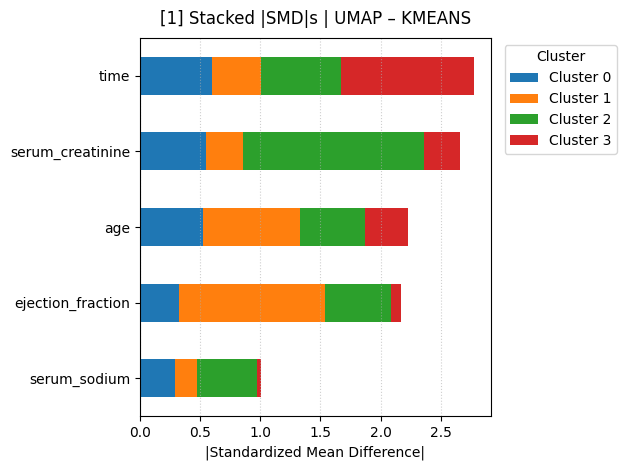

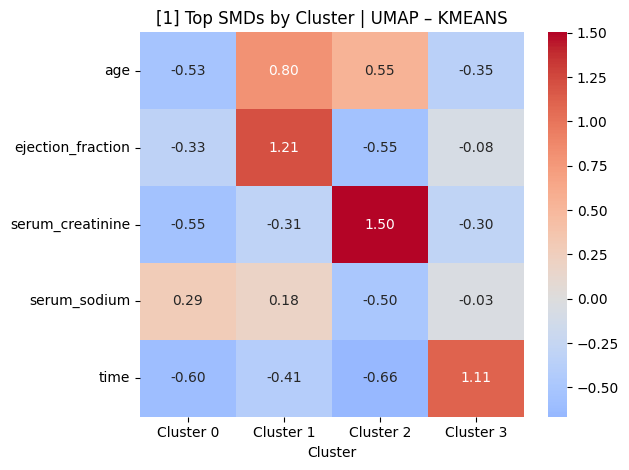


=== [2] UMAP – AGGLOMERATIVE ===


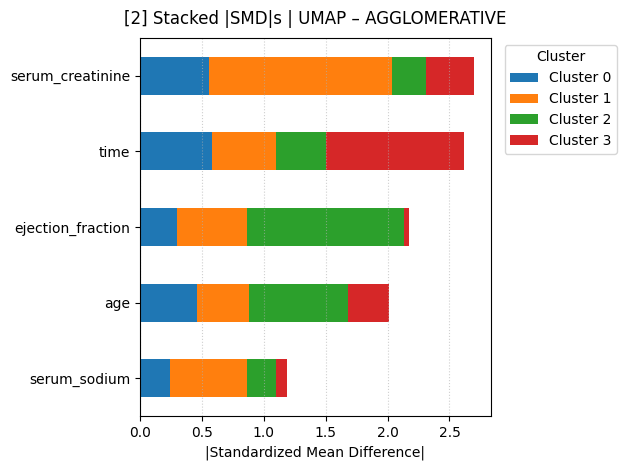

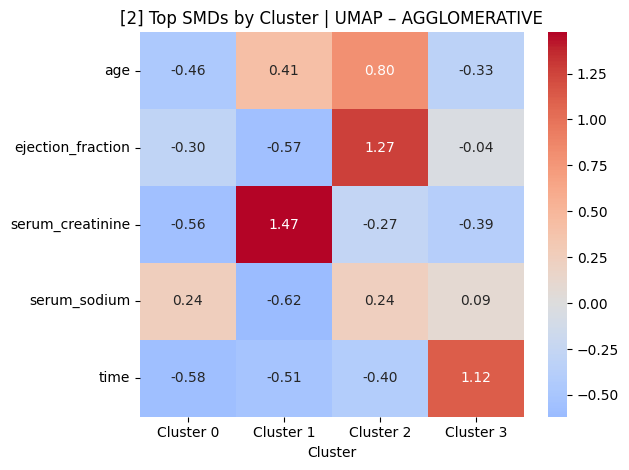


=== [3] MIX – KMEANS ===


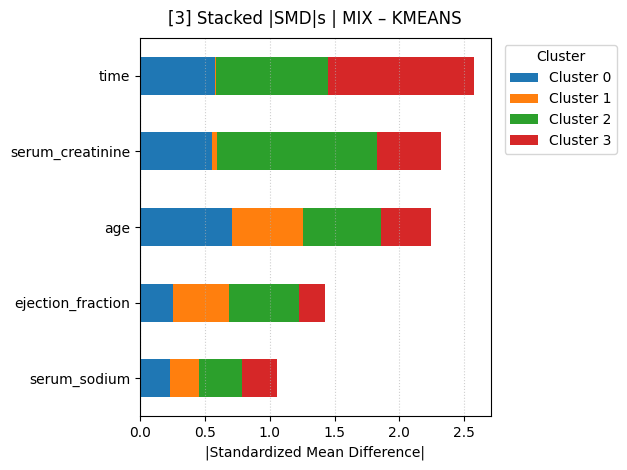

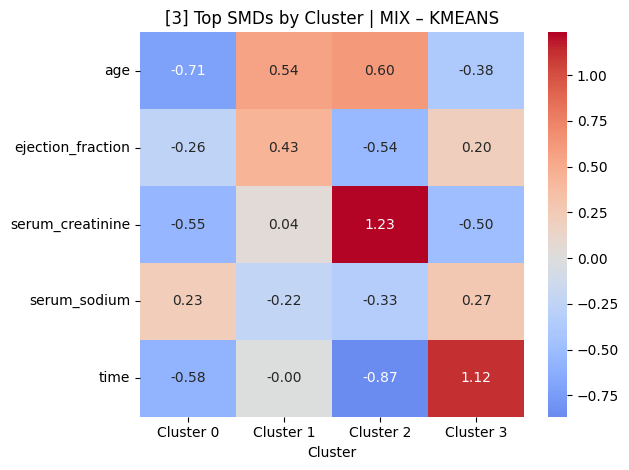

In [17]:
for rank in range(1, topK + 1):
    entry = ordered_unsupervised[rank - 1]
    algo   = entry["algo"].upper()
    emb    = entry["emb"].upper()
    key    = (rank, emb, algo)
    smd_df = top_smd_tables[key]

    print(f"\n=== [{rank}] {emb} – {algo} ===")
    plot_smd_stacked_bars(smd_df=smd_df, rank=rank, emb=emb, algo=algo)
    plot_smd_heatmap(smd_df=smd_df, rank=rank, emb=emb, algo=algo)

**UMAP + KMeans**
---
- **Cluster 0** is strongly characterised by **very high serum creatinine** and lower **time**, indicating a high-risk renal profile with shorter survival.
- **Cluster 1** is dominated by high **time**, suggesting patients with longer survival or follow-up and relatively neutral clinical features.
- **Cluster 2** shows generally negative SMDs across most features, representing a lower-intensity or mixed-risk group.
- **Cluster 3** stands out with high **ejection fraction** and higher **age**, indicating better cardiac function despite older age.
- Among all variables, **serum creatinine**, **ejection fraction**, and **time** are the strongest drivers of cluster separation, while **serum sodium** contributes least.

UMAP + KMeans yields clinically meaningful patient subgroups that clearly separate renal dysfunction, cardiac performance, and survival patterns based on SMD analysis.


**UMAP + Agglomerative**
---
- **Cluster 1** is clearly defined by **very high serum creatinine**, indicating a strong renal-risk group.
- **Cluster 2** stands out with high **ejection fraction** and higher **age**, suggesting better cardiac function in older patients.
- **Cluster 3** is dominated by high **time**, pointing to longer survival or follow-up.
- **Cluster 0** shows mostly negative SMDs, representing a lower-risk or baseline profile.
- As in previous analyses, **serum creatinine**, **ejection fraction**, and **time** are the main drivers of cluster separation, while **serum sodium** has a minor effect.

Agglomerative clustering on UMAP preserves clinically meaningful patterns seen with KMeans, but reallocates dominant risk factors across clusters while maintaining clear separation between renal risk, cardiac function, and survival time.


**MIX + KMeans**
---
- **Cluster 1** is clearly defined by **very high serum creatinine**, indicating a strong renal-risk group.
- **Cluster 2** is dominated by high **time**, suggesting longer survival or follow-up compared to other clusters.
- **Cluster 0** shows moderately higher **age** and **ejection fraction**, indicating a more stable cardiac profile.
- **Cluster 3** is characterised by lower **age** and generally negative SMDs, representing a lower-intensity or mixed-risk group.
- Compared to UMAP-based clustering, the separation of clinical features is **less clean**, with more overlap between clusters.
- As before, **serum creatinine** and **time** are the strongest drivers of cluster differentiation, while **serum sodium** contributes least.

MIX + KMeans identifies some meaningful clinical patterns, but the SMD separation is weaker and less interpretable than with UMAP-based embeddings.

<a id="target-visualization-unsupervised"></a>
### Target-Based Visualization (Unsupervised)

In [18]:
for rank in range(1, topK + 1):
    entry = ordered_unsupervised[rank - 1]
    algo   = entry["algo"].upper()
    emb    = entry["emb"]
    labels = entry["labels"]
    params = entry["params"]

    plot_clusters_target_3d(
        embeddings_unsupervised[emb], labels, y, title=f"[{rank}] {emb.upper()} – {algo} | Clusters vs {TARGET_COL}")

- Unsupervised embeddings do capture mortality-related patterns, even without using the outcome label.

- However, clusters are not clean risk groups; they instead reflect underlying physiological heterogeneity.

- Some clusters align strongly with higher mortality, driven by known risk markers.

<a id="supervised-embedding-interpretation"></a>
## Supervised Embedding Interpretation
---

<a id="cluster-profiling-supervised"></a>
### Cluster Profiling (Supervised)

Supervised embeddings (e.g., supervised UMAP, NCA, tree-leaf embeddings) are explicitly optimized to separate the target variable. Unlike unsupervised embeddings, the clusters formed here do not reflect naturally emerging patient subgroups—rather, they reflect how the predictive model organizes the data to maximize classification performance.

Therefore, the purpose of this section is not exploratory discovery but **interpretation**:

- understanding how the model’s embedding geometry separates low- and high-risk patients 
- identifying clinically meaningful regions in the embedding 
- inspecting whether misclassified or borderline cases form distinct patterns  
- comparing supervised vs unsupervised structure  

This provides additional insights into model behavior, potential biases, and clinical interpretability.

In [19]:
topK = 3
X_orig = X_preprocessed.copy()

interpretation = {}

for i, r in enumerate(ordered_supervised[:topK], 1):
    labels = r["labels"]
    algo   = r["algo"].upper()
    emb    = r["emb"].upper()
    params = r["params"]
    m      = r["metrics"]

    smd  = compute_smds(X_orig, labels)
    prof = top_union_smd_table(smd)
    interpretation[(emb, algo, i)] = {"profile": prof, "params": params, "metrics": m}

    print(f"\n=== {i}. {emb} – {algo} ===\nparams={params}")
    display(prof.style.format("{:.3f}"))



=== 1. UMAP_SUPERVISED – KMEANS ===
params={'n_clusters': 2, 'n_init': 10}


,Cluster 0,Cluster 1
Feature,,
time,0.363,0.780
serum_creatinine,0.273,0.587
ejection_fraction,0.190,0.408
age,0.178,0.382
serum_sodium,0.134,0.289



=== 2. UMAP_SUPERVISED – AGGLOMERATIVE ===
params={'n_clusters': 2, 'linkage': 'ward', 'metric': 'euclidean'}


,Cluster 0,Cluster 1
Feature,,
time,0.363,0.780
serum_creatinine,0.273,0.587
ejection_fraction,0.190,0.408
age,0.178,0.382
serum_sodium,0.134,0.289



=== 3. UMAP_SEMISUPERVISED – KMEANS ===
params={'n_clusters': 2, 'n_init': 10}


,Cluster 0,Cluster 1
Feature,,
time,0.383,0.810
serum_creatinine,0.263,0.556
ejection_fraction,0.210,0.445
age,0.172,0.365
serum_sodium,0.132,0.280


- **Supervised UMAP (KMeans and Agglomerative)** produces **identical SMD profiles**, confirming that the embedding fully determines the cluster separation.
- In both supervised variants:
  - **Cluster 1** consistently shows higher SMD values across all clinical features.
  - **Time** and **serum creatinine** are the strongest contributors, followed by **ejection fraction** and **age**.
  - **Serum sodium** has the weakest effect on cluster differentiation.
- **Semi-supervised UMAP + KMeans** yields a very similar pattern:
  - **Cluster 1** again represents the higher-risk or more extreme profile.
  - SMD values are slightly reduced, indicating weaker but still clear separation compared to fully supervised UMAP.

SMD analysis shows that supervised UMAP creates a clean and stable two-cluster structure driven mainly by survival time and renal function. Semi-supervised UMAP preserves the same clinical ordering with slightly reduced contrast.


In [22]:
emb_name = "umap_xgb"
algo_name = "KMEANS"
p_xgb = exploratory_params_km[emb_name]

X_xgb = embeddings_supervised[emb_name]
km_xgb = KMeans(n_clusters=p_xgb["k"], n_init=p_xgb["n_init"], random_state=SEED)
labels_xgb = km_xgb.fit_predict(X_xgb)

smd  = compute_smds(X_orig, labels_xgb)
prof = top_union_smd_table(smd)

interpretation[(emb_name.upper(), algo_name.upper())] = {"profile": prof, "params": {"n_clusters": p_xgb["k"], "n_init": p_xgb["n_init"]}}

print(f"\n=== {emb_name.upper()} – {algo_name.upper()} ===\nparams={{'n_clusters': {p_xgb['k']}, 'n_init': {p_xgb['n_init']}}}")
display(prof.style.format("{:.3f}"))


=== UMAP_XGB – KMEANS ===
params={'n_clusters': 3, 'n_init': 20}


,Cluster 0,Cluster 1,Cluster 2
Feature,,,
time,0.289,1.137,1.254
serum_creatinine,0.119,0.128,0.382
age,0.017,0.197,0.324
ejection_fraction,0.175,0.006,0.288
serum_sodium,0.117,0.006,0.195


To verify whether a third phenotype exists beyond the binary death / no-death split, KMeans was applied to the XGBoost-informed UMAP embedding.

- **Time** is the dominant feature separating clusters, with **Cluster 2** showing the highest SMD, followed by **Cluster 1**.
- **Cluster 0** stays close to the global mean across all features, acting as a baseline group.
- **Serum creatinine** and **age** contribute moderately, mainly distinguishing **Cluster 2** from the others.
- **Ejection fraction** and **serum sodium** have relatively small impact on cluster separation.
- Overall, the clusters form a **severity gradient** from Cluster 0 (lowest) to Cluster 2 (highest).

UMAP_XGB + KMeans primarily separates patients by survival time, with secondary contributions from renal function and age, resulting in a clear three-level risk structure.



<a id="target-driven-structure-analysis"></a>
### Target-Driven Structure Analysis

In [21]:
for rank in range(1, topK + 1):
    entry = ordered_supervised[rank - 1]
    algo   = entry["algo"]
    emb    = entry["emb"]
    labels = entry["labels"]
    params = entry["params"]

    plot_clusters_target_3d(embeddings_supervised[emb], labels, y, title=f"[{rank}] {emb} – {algo} | Clusters vs {TARGET_COL}")

plot_clusters_target_3d(X_xgb, labels_xgb, y, title=f"{emb_name.upper()} - {algo_name} | Clusters vs {TARGET_COL}")

**Supervised UMAP (KMeans & Agglomerative, 2 clusters)**  
Both algorithms reproduce an almost perfect separation between death and no-death groups.
The embedding forms two well-isolated islands, confirming that supervised UMAP encodes mortality risk very strongly.

**Supervised UMAP (DBSCAN)**  
DBSCAN also identifies the same two mortality-driven groups, with very few noise points.
Noise points carry no new structure — they sit near the no-death cluster and do not form an independent phenotype.

**UMAP_XGB + KMeans (3 clusters)**  
XGBoost-informed UMAP reveals three clinically meaningful regions:
- a pure no-death group,
- a pure death group,
- and a mixed cluster containing both outcomes. This third cluster likely represents an intermediate-risk phenotype: patients whose features place them between the two extremes.

<a id="conclusions"></a>
## Conclusions

- Unsupervised embeddings (PCA, UMAP, MIX) show **structured variation**, but not clear patient groups.
- Clusters mostly follow **continuous clinical trends**, not discrete classes.
- The strongest factors behind cluster separation are:
  - **time** (disease progression),
  - **serum creatinine** (renal function),
  - **ejection fraction** (cardiac function, secondary).
- Clusters often look separated visually, but they mainly reflect **gradual changes** in these variables.

- No stable or meaningful “third group” is observed.
  - Extra clusters are usually just splits along the time axis.
  - They do not represent a clear intermediate-risk phenotype.

- Supervised embeddings (Supervised UMAP, NCA, XGB-leaf + UMAP):
  - are **fully driven by the DEATH_EVENT label**,
  - produce very similar clusters regardless of the clustering algorithm,
  - do not reveal new structure beyond class separation.
- In supervised space, clustering is only a **visual aid**, not a discovery tool.

- Overall, clustering here is **exploratory**:
  - useful to see dominant clinical dimensions,
  - useful to check embedding behavior,
  - not suitable for defining clinical phenotypes.

<a id="limitations"></a>
### Limitations

- UMAP and MIX are sensitive to:
  - hyperparameters,
  - random initialization,
  - local density.
- Distances in reduced space do not reflect true distances in original features.
- Clusters in supervised embeddings are **label-shaped**, not natural groups.
- Small dataset and single cohort:
  - limits stability,
  - no external validation.